# Data Preparation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
## load the data
from pandas import read_csv
data = read_csv('/content/drive/MyDrive/Dataset/data.csv', low_memory=False)

## Data Reading

In [4]:
## display first 5 rows
data.head()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,281566,IE,IP-04-KNA-2018-0010,KIA,KIA,KIA MOTORS CORPORATION,KIA,e4*2007/46*1018*07,JF,A5D51,...,NaN,NaN,NaN,F,2019,NaN,NaN,NaN,NaN,NaN
1,275305,IE,IP-02-UU1-2018-0007,RENAULT,DACIA,AUTOMOBILE DACIA SA,DACIA,E2*2001/116*0314*88,SD,05DV,...,NaN,NaN,NaN,F,2019,NaN,NaN,NaN,NaN,NaN
2,275797,IE,IP-9-WF0-2018-0003,FORD-WERKE GMBH,FORD WERKE GMBH,FORD-WERKE GMBH,Ford,e9*2007/46*3142*08,JHH,SFJN1JX,...,NaN,NaN,NaN,F,2019,NaN,NaN,NaN,NaN,NaN
3,276485,IE,IP-02-UU1-2018-0007,RENAULT,DACIA,AUTOMOBILE DACIA SA,DACIA,E2*2001/116*0314*88,SD,05DV,...,NaN,NaN,NaN,F,2019,NaN,NaN,NaN,NaN,NaN
4,276644,IE,IP-9-WF0-2018-0003,FORD-WERKE GMBH,FORD WERKE GMBH,FORD-WERKE GMBH,Ford,e9*2007/46*3142*08,JHH,SFJN1JX,...,NaN,NaN,NaN,F,2019,NaN,NaN,NaN,NaN,NaN


In [5]:
## provide the metadata
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536402 entries, 0 to 536401
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    536402 non-null  int64  
 1   Country               536402 non-null  object 
 2   VFN                   513493 non-null  object 
 3   Mp                    508471 non-null  object 
 4   Mh                    536402 non-null  object 
 5   Man                   536402 non-null  object 
 6   MMS                   203164 non-null  object 
 7   Tan                   536372 non-null  object 
 8   T                     534595 non-null  object 
 9   Va                    536402 non-null  object 
 10  Ve                    536402 non-null  object 
 11  Mk                    536399 non-null  object 
 12  Cn                    536401 non-null  object 
 13  Ct                    536402 non-null  object 
 14  Cr                    536402 non-null  object 
 15  

## Selecting only relevant input features

The relevant input features identified are as follows:

*   *Ct* - Category of the vehicle type approved.
*   *Mt* - WLTP test mass (weight of the vehicle in kg)
*   *Ft* - Fuel Type
*   *ec (cm3)* - Engine Capacity
*   *ep (KW)* - Engine Power
*   *Ewltp (g/km)* **(Target Variable)** - Specific CO2 Emissions


In [6]:
data1 = data[['Ct','Mt','Ewltp (g/km)','Ft','ec (cm3)','ep (KW)']]

In [7]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536402 entries, 0 to 536401
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Ct            536402 non-null  object 
 1   Mt            514064 non-null  float64
 2   Ewltp (g/km)  525544 non-null  float64
 3   Ft            536402 non-null  object 
 4   ec (cm3)      481642 non-null  float64
 5   ep (KW)       531704 non-null  float64
dtypes: float64(4), object(2)
memory usage: 24.6+ MB


## Data Cleaning

In [8]:
data1['Ct'].value_counts()

,count
Ct,
M1,528605
M1G,7797


In [9]:
data1['Ft'].value_counts()

,count
Ft,
petrol,166180
diesel,112665
PETROL,93719
DIESEL,76447
electric,41685
petrol/electric,20836
ELECTRIC,12665
PETROL/ELECTRIC,10230
diesel/electric,821


In [10]:
fuel_map = {
    "PETROL": "petrol",
    "DIESEL": "diesel",
    "PETROL/ELECTRIC": "petrol/electric",
    "ELECTRIC": "electric",
    "LPG": "lpg",
    "DIESEL/ELECTRIC": "diesel/electric"
}

data1['Ft'] = data1['Ft'].replace(fuel_map)

# check results
data1['Ft'].value_counts()


/tmp/ipykernel_7655/1201181856.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Ft'] = data1['Ft'].replace(fuel_map)


,count
Ft,
petrol,259899
diesel,189112
electric,54350
petrol/electric,31066
diesel/electric,1082
lpg,893


In [11]:
## Check how many values are NULL for the target variable
null_values = data1['Ewltp (g/km)'].isnull().sum()

## Remove rows where target variable value is NULL
data1 = data1.dropna(subset=['Ewltp (g/km)'], ignore_index=True)  ## re-arranges the indexes after rows dropped

print("Rows dropped that has NULL value for target variable (Ewltp (g/km)): ", null_values)


Rows dropped that has NULL value for target variable (Ewltp (g/km)):  10858


In [12]:
## Fill missing values, except for 'Ct' and 'Ft', as they have no NULL values

list1 = ['Mt','ec (cm3)','ep (KW)']
for i in list1:
  mean = data1[i].mean()
  data1[i]=data1[i].fillna(mean)

In [13]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525544 entries, 0 to 525543
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Ct            525544 non-null  object 
 1   Mt            525544 non-null  float64
 2   Ewltp (g/km)  525544 non-null  float64
 3   Ft            525544 non-null  object 
 4   ec (cm3)      525544 non-null  float64
 5   ep (KW)       525544 non-null  float64
dtypes: float64(4), object(2)
memory usage: 24.1+ MB


## Data Encoding

In [14]:
from pandas import get_dummies
data1 = get_dummies(data1, columns = ['Ct', 'Ft'], dtype=int)
data1

,Mt,Ewltp (g/km),ec (cm3),ep (KW),Ct_M1,Ct_M1G,Ft_diesel,Ft_diesel/electric,Ft_electric,Ft_lpg,Ft_petrol,Ft_petrol/electric
0,1633.614932,137.0,1598.00000,100.000000,1,0,1,0,0,0,0,0
1,1353.000000,126.0,1461.00000,70.000000,1,0,1,0,0,0,0,0
2,1349.000000,135.0,998.00000,74.000000,1,0,0,0,0,0,1,0
3,1353.000000,126.0,1461.00000,70.000000,1,0,1,0,0,0,0,0
4,1341.000000,135.0,998.00000,74.000000,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
525539,1851.000000,185.0,1995.00000,110.000000,1,0,0,0,0,0,1,0
525540,1851.000000,185.0,1995.00000,110.000000,1,0,0,0,0,0,1,0
525541,1851.000000,185.0,1995.00000,110.000000,1,0,0,0,0,0,1,0
525542,1851.000000,185.0,1995.00000,110.000000,1,0,0,0,0,0,1,0


In [15]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525544 entries, 0 to 525543
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Mt                  525544 non-null  float64
 1   Ewltp (g/km)        525544 non-null  float64
 2   ec (cm3)            525544 non-null  float64
 3   ep (KW)             525544 non-null  float64
 4   Ct_M1               525544 non-null  int64  
 5   Ct_M1G              525544 non-null  int64  
 6   Ft_diesel           525544 non-null  int64  
 7   Ft_diesel/electric  525544 non-null  int64  
 8   Ft_electric         525544 non-null  int64  
 9   Ft_lpg              525544 non-null  int64  
 10  Ft_petrol           525544 non-null  int64  
 11  Ft_petrol/electric  525544 non-null  int64  
dtypes: float64(4), int64(8)
memory usage: 48.1 MB


In [16]:
## save the encoded data
data1.to_csv('/content/drive/MyDrive/Dataset/data1.csv', index=False)

## Divide the dataset into x and y

In [17]:
y = data1['Ewltp (g/km)']
x = data1.drop('Ewltp (g/km)',axis=1)

## evaluate their shape
print("Shape of x: ", x.shape)
print("Shape of y: ", y.shape)

Shape of x:  (525544, 11)
Shape of y:  (525544,)


## Data Scaling (x only)

In [18]:
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

x_scaled = StandardScaler().fit_transform(x)
DataFrame(x_scaled)

,0,1,2,3,4,5,6,7,8,9,10
0,-7.370789e-16,1.034160e-01,-8.188238e-03,0.121077,-0.121077,1.365318,-0.045421,-0.338512,-0.041256,-0.973758,-0.247168
1,-9.096715e-01,-2.258276e-01,-7.728185e-01,0.121077,-0.121077,1.365318,-0.045421,-0.338512,-0.041256,-0.973758,-0.247168
2,-9.226383e-01,-1.338527e+00,-6.708678e-01,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
3,-9.096715e-01,-2.258276e-01,-7.728185e-01,0.121077,-0.121077,1.365318,-0.045421,-0.338512,-0.041256,-0.973758,-0.247168
4,-9.485719e-01,-1.338527e+00,-6.708678e-01,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
...,...,...,...,...,...,...,...,...,...,...,...
525539,7.046987e-01,1.057502e+00,2.466885e-01,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
525540,7.046987e-01,1.057502e+00,2.466885e-01,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
525541,7.046987e-01,1.057502e+00,2.466885e-01,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
525542,7.046987e-01,1.057502e+00,2.466885e-01,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168


## Data Splitting

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.20, random_state=100)
print("X and Y Train Set")
print(x_train.shape)
print(y_train.shape)

print("\nX and Y Test Set")
print(x_test.shape)
print(y_test.shape)

X and Y Train Set
(420435, 11)
(420435,)

X and Y Test Set
(105109, 11)
(105109,)


# Linear Regression

In [20]:
from statsmodels.api import OLS, add_constant

x_scaled_with_constant = add_constant(x_scaled)
model = OLS(y, x_scaled_with_constant)
best_model = model.fit()
print(best_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Ewltp (g/km)   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                 5.935e+05
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:55:08   Log-Likelihood:            -2.1540e+06
No. Observations:              525544   AIC:                         4.308e+06
Df Residuals:                  525534   BIC:                         4.308e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.0901      0.020   5672.612      0.0

# Support Vector Regressor

The dataset is too big for the SVR, using below code to create a random sample from the dataset.

In [21]:
## Random Sampling for x_scaled and y
from sklearn.utils import resample
x_sample, y_sample = resample(x_scaled, y, n_samples=2000, random_state=42)
print("x_scaled and y shape")
print(x_scaled.shape)
print(y.shape)
print("\nX and Y Sample Shape")
print(x_sample.shape)
print(y_sample.shape)

x_train_svr, x_test_svr, y_train_svr, y_test_svr = train_test_split(x_sample, y_sample, test_size=0.20, random_state=100)
print ("\n X and Y Training Set")
print(x_train_svr.shape)
print(y_train_svr.shape)
print ("\nX and Y Test Set")
print(x_test_svr.shape)
print(y_test_svr.shape)

x_scaled and y shape
(525544, 11)
(525544,)

X and Y Sample Shape
(2000, 11)
(2000,)

 X and Y Training Set
(1600, 11)
(1600,)

X and Y Test Set
(400, 11)
(400,)


## Method 1

### Modelling

In [22]:
from sklearn.svm import SVR
SV_regressor1 = SVR(kernel='rbf', C=10, epsilon=0.5) ## build
SV_regressor1.fit(x_sample,y_sample) ## train
y_pred1 = SV_regressor1.predict(x_test) ## test

### Evaluation

In [23]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test,y_pred1)
print('R2 = ', round(R2*100,2),'%')

R2 =  91.59 %


## Method 2 - *Using GridSearchCV*

In [24]:
from sklearn.model_selection import GridSearchCV
SV_regressor2 = SVR()
k_c_e = {'kernel':['linear','poly','rbf','sigmoid'],
         'C':[1, 5, 10, 15],
         'epsilon':[1, 4, 6, 7]}

grid_search3 = GridSearchCV(estimator=SV_regressor2, param_grid=k_c_e, scoring= 'r2', cv=5)
grid_search3.fit(x_sample,y_sample)

best_k_c_e = grid_search3.best_params_

R2 = grid_search3.best_score_
print("R2 = " ,round(R2*100,2), "%")
best_svr = grid_search3.best_estimator_
print(best_svr)

R2 =  93.2 %
SVR(C=15, epsilon=1, kernel='poly')


# Save the Best SVR Model

In [25]:
import joblib
joblib.dump(best_svr, '/content/best_svr.pkl')

['/content/best_svr.pkl']

In [26]:
## In a new colab page, run below code
import joblib
best_svr = joblib.load('/content/best_svr.pkl')

# Uploading New Data to Predict CO2 Emissions

Attached below is a snapshot of the new data that is uploaded.
File name: *input.csv*

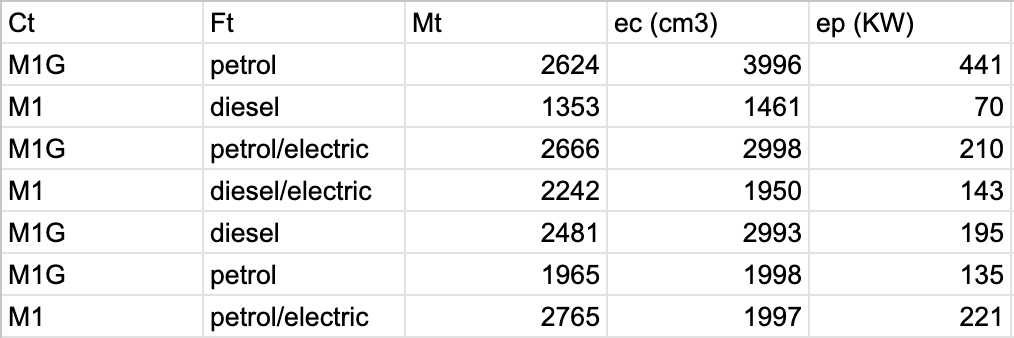

## Data Reading

In [27]:
"""Uploading new data"""

new_data = read_csv('/content/drive/MyDrive/Input File/input.csv')
new_data

,Ct,Ft,Mt,ec (cm3),ep (KW)
0,M1G,petrol,2624,3996,441
1,M1,diesel,1353,1461,70
2,M1G,petrol/electric,2666,2998,210
3,M1,diesel/electric,2242,1950,143
4,M1G,diesel,2481,2993,195
5,M1G,petrol,1965,1998,135
6,M1,petrol/electric,2765,1997,221


## Data Encoding

In [28]:
enc_new_data = get_dummies(new_data, columns = ['Ct', 'Ft'], dtype=int)
enc_new_data = enc_new_data.reindex(columns=x.columns, fill_value=0)

enc_new_data

,Mt,ec (cm3),ep (KW),Ct_M1,Ct_M1G,Ft_diesel,Ft_diesel/electric,Ft_electric,Ft_lpg,Ft_petrol,Ft_petrol/electric
0,2624,3996,441,0,1,0,0,0,0,1,0
1,1353,1461,70,1,0,1,0,0,0,0,0
2,2666,2998,210,0,1,0,0,0,0,0,1
3,2242,1950,143,1,0,0,1,0,0,0,0
4,2481,2993,195,0,1,1,0,0,0,0,0
5,1965,1998,135,0,1,0,0,0,0,1,0
6,2765,1997,221,1,0,0,0,0,0,0,1


In [29]:
print(enc_new_data.shape)

(7, 11)


## Data Scaling

In [30]:
scaled_new_data = StandardScaler().fit(x).transform(enc_new_data)
DataFrame(scaled_new_data)

,0,1,2,3,4,5,6,7,8,9,10
0,3.210538,5.866382,8.683110,-8.259193,8.259193,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
1,-0.909671,-0.225828,-0.772819,0.121077,-0.121077,1.365318,-0.045421,-0.338512,-0.041256,-0.973758,-0.247168
2,3.346690,3.467950,2.795456,-8.259193,8.259193,-0.732430,-0.045421,-0.338512,-0.041256,-0.973758,4.045833
3,1.972206,0.949356,1.087782,0.121077,-0.121077,-0.732430,22.016252,-0.338512,-0.041256,-0.973758,-0.247168
4,2.746974,3.455934,2.413141,-8.259193,8.259193,1.365318,-0.045421,-0.338512,-0.041256,-0.973758,-0.247168
5,1.074253,1.064711,0.883880,-8.259193,8.259193,-0.732430,-0.045421,-0.338512,-0.041256,1.026949,-0.247168
6,3.667619,1.062308,3.075821,0.121077,-0.121077,-0.732430,-0.045421,-0.338512,-0.041256,-0.973758,4.045833


In [31]:
scaled_new_data.shape

(7, 11)

In [32]:
## In LR, constant (the intercept) is added as a new column.
## Therefore, this step is necessary.

import numpy as np
scaled_new_data_for_lr = np.insert(scaled_new_data,0,1,axis=1)
scaled_new_data_for_lr.shape

(7, 12)

## Prediction using Linear Regression

In [33]:
lr_prediction = best_model.predict(scaled_new_data_for_lr)
lr_prediction = DataFrame(lr_prediction)
print("CO2 Emissions Prediction Using Linear Regression")
lr_prediction

CO2 Emissions Prediction Using Linear Regression


,0
0,182.610588
1,128.552781
2,48.383112
3,21.447086
4,165.278637
5,144.342592
6,68.597657


## Prediction using Support Vector Regression

In [34]:
svr_prediction = best_svr.predict(scaled_new_data)
svr_prediction = DataFrame(svr_prediction)
print("CO2 Emissions Prediction Using Support Vector Regression")
svr_prediction

CO2 Emissions Prediction Using Support Vector Regression


,0
0,388.136931
1,125.157450
2,31.002501
3,29.466220
4,205.762959
5,177.033877
6,75.565261
